# The Hemker problem

Donea, J. & Huerta, A. (2003). *Finite Element Methods for Flow Problems*. $\S 2.6.6$

$$
\begin{cases}
\Omega = [-1, 1] \\
u_{\text{D}}(x=-1)=-2 \\
u_{\text{D}}(x=1)=0 \\
\textbf{a}=x\,\textbf{e}_x \\
\mathsf{D}=-\nu\mathsf{I} \\
R=0 \\
J = -D\pi^2\cos(\pi x) -\pi x\sin(\pi x) \\
u_{\text{e}}(x)=\cos(\pi x)+\frac{\text{erf}\left(\frac{x}{\sqrt{2D}}\right)}{\text{erf}\left(\frac{1}{\sqrt{2D}}\right)}
\end{cases}
$$

In [ ]:
import numpy as np
import scipy.special as sp
from ufl import SpatialCoordinate, as_vector, cos, sin, CellDiameter
from lucifex.mesh import interval_mesh
from lucifex.fem import Function, Constant
from lucifex.solver import BoundaryValueProblem, bvp, BoundaryConditions
from lucifex.viz import plot_line, save_figure
from lucifex.utils.py_utils import nested_dict
from lucifex.pde.advection_diffusion import steady_advection_diffusion

def create_solver(
    supg: str | None,
    Nx: int,
    nu: float, 
    Lx: tuple[float, float] = (-1.0, 1.0),
    dirichlet: tuple[float, float] = (-2.0, 0.0),
) -> BoundaryValueProblem:
    mesh = interval_mesh(Lx, Nx)
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0] - Lx[0], dirichlet[0]),
        ('dirichlet', lambda x: x[0] - Lx[1], dirichlet[1])
    )
    x = SpatialCoordinate(mesh)
    a = as_vector((x[0], ))
    d = Constant(mesh, -nu, name='d')
    nu = Constant(mesh, nu, name='nu')
    j = -nu * np.pi**2 * cos(np.pi * x[0]) - np.pi * x[0] * sin(np.pi * x[0])
    u = Function((mesh, 'P', 1), name='u')
    h = CellDiameter(mesh)
    u_solver = bvp(steady_advection_diffusion, bcs=bcs)(
        u, a, d, j=j, supg=supg, h=h,
    )
    return u_solver


Lx = (-1.0, 1.0)
Nx = 20
nu = 1e-6
supg_opts = (None, 'coth')
solutions: dict[str | None, Function] = nested_dict()

for supg in supg_opts:
    u_solver = create_solver(supg, Nx, nu, Lx)
    u_solver.solve()
    solutions[supg] = u_solver.solution

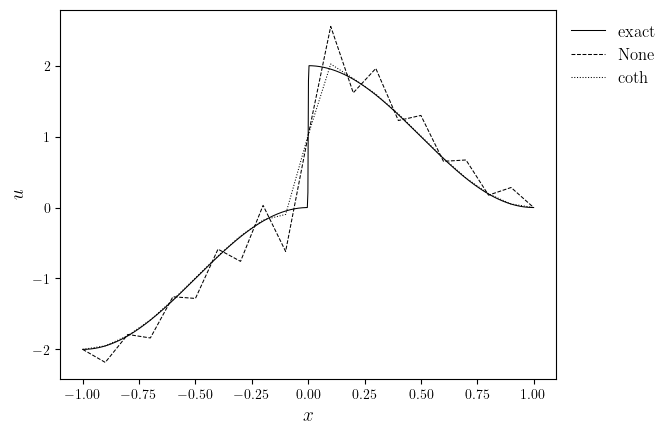

In [3]:
def exact_solution(
    x: np.ndarray,   
    d: float,
) -> np.ndarray:    
    return np.cos(np.pi * x) + sp.erf(x/np.sqrt(2 * d)) / sp.erf(1/np.sqrt(2 * d))


x = np.linspace(*Lx, num=800)

lines = [(x, exact_solution(x, nu))]
legend_labels = ['exact']
for supg in supg_opts:
    lines.append(solutions[supg])
    legend_labels.append(supg)

fig, ax = plot_line(lines, legend_labels, x_label='$x$', y_label='$u$')
save_figure('hemker')(fig)